# 📊 Peak Analysis - Determine Major Bleeding Threshold

**Goal**: Analyze all detected peaks to determine what constitutes a "major" bleeding event

**Why**: We have too many minor peaks. We need to focus on clinically significant bleeding.

**Output**: Optimal threshold for filtering peaks

In [1]:
# Cell 1: Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.signal import find_peaks
from tqdm import tqdm

print("✅ Imports complete")

✅ Imports complete


In [2]:
# Cell 2: Load All Aligned Data
ALIGNED_DIR = Path("cleaned_aligned_dataset/aligned_dataset")

print(f"Loading aligned datasets from: {ALIGNED_DIR}\n")

aligned_files = sorted(ALIGNED_DIR.glob("*_aligned.npz"))
print(f"Found {len(aligned_files)} aligned files")

all_data = {}

for aligned_file in tqdm(aligned_files, desc="Loading"):
    video_id = aligned_file.stem.replace('_aligned', '')
    data = np.load(aligned_file, allow_pickle=True)
    
    all_data[video_id] = {
        'blood_areas': data['blood_areas'],
        'smoothed_blood_areas': data['smoothed_blood_areas'],
        'peaks': data['peaks'],
        'num_frames': len(data['blood_areas'])
    }

print(f"\n✅ Loaded {len(all_data)} videos")

Loading aligned datasets from: cleaned_aligned_dataset/aligned_dataset

Found 45 aligned files


Loading: 100%|█████████████████████████████████████████████████████████████████████████████████████| 45/45 [00:00<00:00, 1529.23it/s]


✅ Loaded 45 videos


In [3]:
# Cell 3: Extract All Peak Information
print("\n" + "=" * 80)
print("EXTRACTING PEAK STATISTICS")
print("=" * 80)
print()

all_peak_heights = []
video_peak_stats = []

for video_id, data in all_data.items():
    smoothed_blood = data['smoothed_blood_areas']
    peaks = data['peaks']
    
    if len(peaks) > 0:
        # Get heights of all peaks in this video
        peak_heights = smoothed_blood[peaks]
        all_peak_heights.extend(peak_heights)
        
        # Video statistics
        video_stats = {
            'video_id': video_id,
            'num_frames': data['num_frames'],
            'num_peaks': len(peaks),
            'mean_blood': np.mean(smoothed_blood),
            'max_blood': np.max(smoothed_blood),
            'mean_peak_height': np.mean(peak_heights),
            'median_peak_height': np.median(peak_heights),
            'max_peak_height': np.max(peak_heights),
            'min_peak_height': np.min(peak_heights),
        }
        video_peak_stats.append(video_stats)

all_peak_heights = np.array(all_peak_heights)
stats_df = pd.DataFrame(video_peak_stats)

print(f"Total peaks across all videos: {len(all_peak_heights)}")
print(f"Videos analyzed: {len(stats_df)}")

# Overall statistics
print(f"\n📊 PEAK HEIGHT DISTRIBUTION:")
print(f"-" * 80)
print(f"  Mean:   {np.mean(all_peak_heights):>10.1f} pixels")
print(f"  Median: {np.median(all_peak_heights):>10.1f} pixels")
print(f"  Std:    {np.std(all_peak_heights):>10.1f} pixels")
print(f"  Min:    {np.min(all_peak_heights):>10.1f} pixels")
print(f"  Max:    {np.max(all_peak_heights):>10.1f} pixels")

print(f"\n📈 PERCENTILES:")
print(f"-" * 80)
for p in [10, 25, 50, 75, 90, 95, 99]:
    val = np.percentile(all_peak_heights, p)
    count = np.sum(all_peak_heights >= val)
    pct = 100 * count / len(all_peak_heights)
    print(f"  {p:2d}th percentile: {val:>10.1f} pixels  ({count:>4d} peaks, {pct:>5.1f}%)")


EXTRACTING PEAK STATISTICS

Total peaks across all videos: 1226
Videos analyzed: 45

📊 PEAK HEIGHT DISTRIBUTION:
--------------------------------------------------------------------------------
  Mean:       7616.0 pixels
  Median:     5519.5 pixels
  Std:        6952.0 pixels
  Min:         136.8 pixels
  Max:       45973.2 pixels

📈 PERCENTILES:
--------------------------------------------------------------------------------
  10th percentile:     1241.5 pixels  (1103 peaks,  90.0%)
  25th percentile:     2389.4 pixels  ( 919 peaks,  75.0%)
  50th percentile:     5519.5 pixels  ( 613 peaks,  50.0%)
  75th percentile:    10602.4 pixels  ( 307 peaks,  25.0%)
  90th percentile:    17682.4 pixels  ( 123 peaks,  10.0%)
  95th percentile:    22157.7 pixels  (  62 peaks,   5.1%)
  99th percentile:    30123.3 pixels  (  13 peaks,   1.1%)



Creating peak distribution visualizations...



/tmp/ipykernel_3513348/2022361112.py:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax5.boxplot(peak_data_sample, labels=video_ids_sample, patch_artist=True)


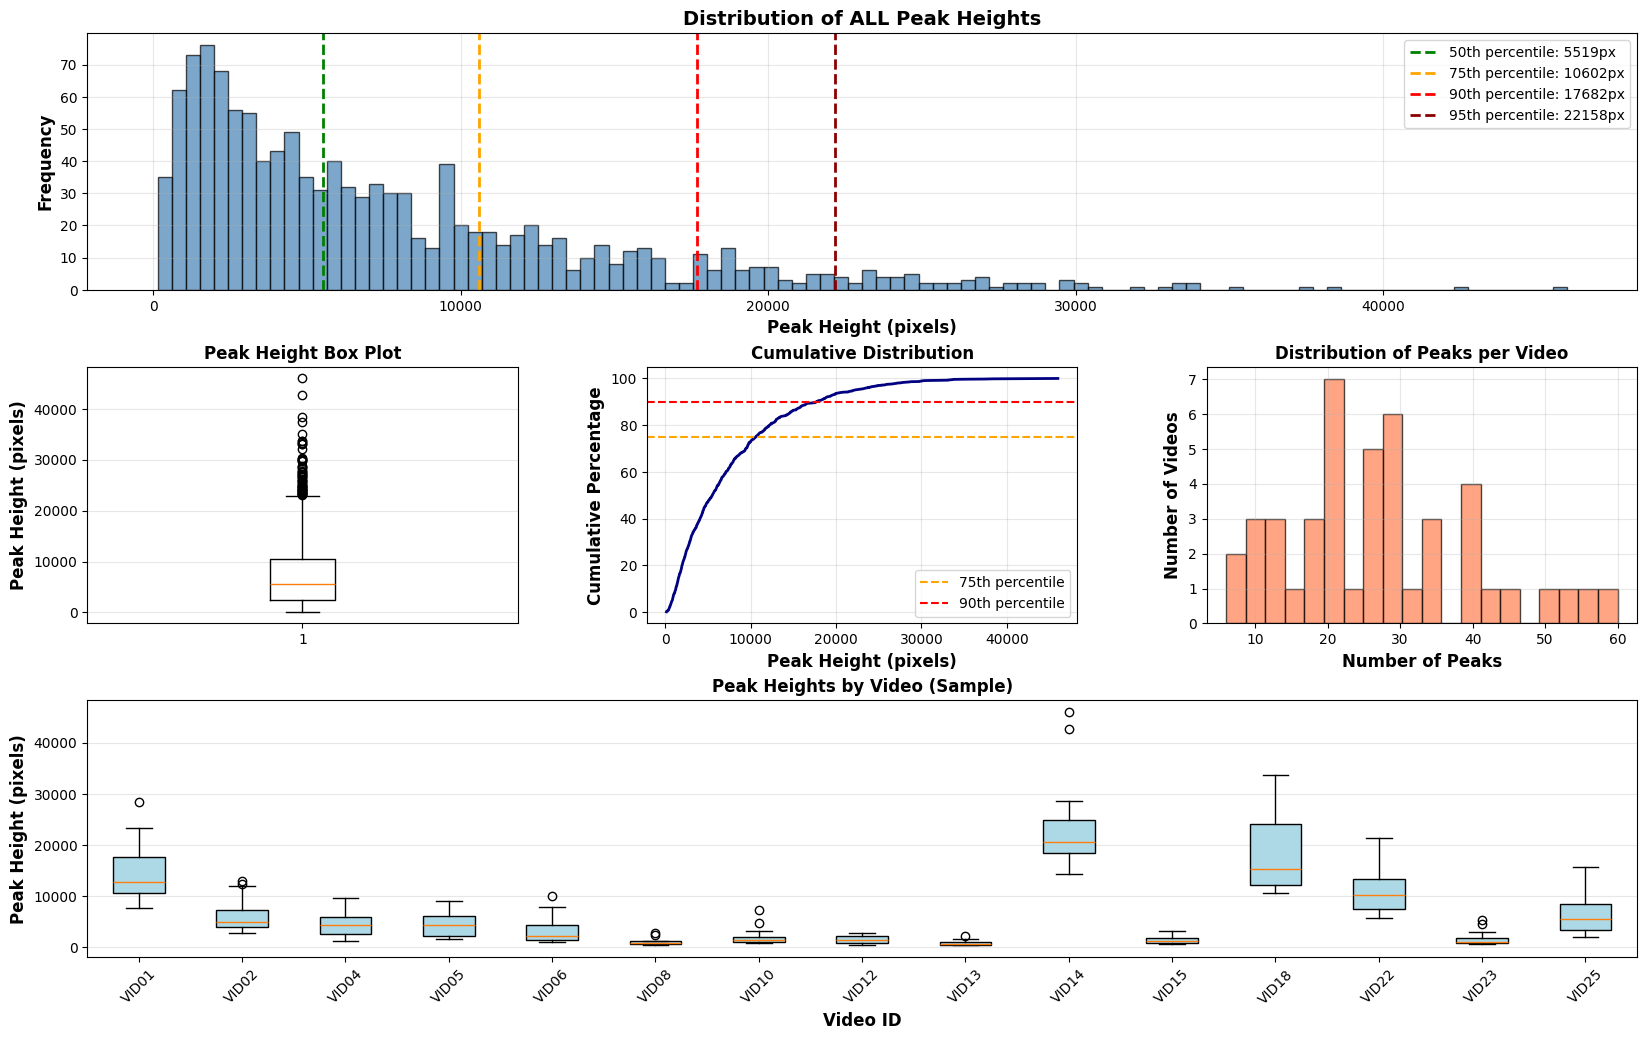

✅ Peak distribution visualization saved


In [4]:
# Cell 4: Visualize Peak Distribution
print("\nCreating peak distribution visualizations...\n")

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Histogram of all peak heights
ax1 = fig.add_subplot(gs[0, :])
ax1.hist(all_peak_heights, bins=100, edgecolor='black', alpha=0.7, color='steelblue')

# Add percentile lines
percentiles = [50, 75, 90, 95]
colors = ['green', 'orange', 'red', 'darkred']
for p, color in zip(percentiles, colors):
    val = np.percentile(all_peak_heights, p)
    ax1.axvline(val, color=color, linestyle='--', linewidth=2,
               label=f'{p}th percentile: {val:.0f}px')

ax1.set_xlabel('Peak Height (pixels)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax1.set_title('Distribution of ALL Peak Heights', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

# 2. Box plot
ax2 = fig.add_subplot(gs[1, 0])
ax2.boxplot(all_peak_heights, vert=True)
ax2.set_ylabel('Peak Height (pixels)', fontsize=12, fontweight='bold')
ax2.set_title('Peak Height Box Plot', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# 3. Cumulative distribution
ax3 = fig.add_subplot(gs[1, 1])
sorted_peaks = np.sort(all_peak_heights)
cumulative = np.arange(1, len(sorted_peaks) + 1) / len(sorted_peaks) * 100
ax3.plot(sorted_peaks, cumulative, linewidth=2, color='navy')
ax3.axhline(75, color='orange', linestyle='--', label='75th percentile')
ax3.axhline(90, color='red', linestyle='--', label='90th percentile')
ax3.set_xlabel('Peak Height (pixels)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Cumulative Percentage', fontsize=12, fontweight='bold')
ax3.set_title('Cumulative Distribution', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Peaks per video
ax4 = fig.add_subplot(gs[1, 2])
ax4.hist(stats_df['num_peaks'], bins=20, edgecolor='black', alpha=0.7, color='coral')
ax4.set_xlabel('Number of Peaks', fontsize=12, fontweight='bold')
ax4.set_ylabel('Number of Videos', fontsize=12, fontweight='bold')
ax4.set_title('Distribution of Peaks per Video', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

# 5. Peak heights by video (first 15 videos)
ax5 = fig.add_subplot(gs[2, :])
video_ids_sample = stats_df['video_id'].head(15).tolist()
peak_data_sample = []
for vid in video_ids_sample:
    data = all_data[vid]
    if len(data['peaks']) > 0:
        peak_data_sample.append(data['smoothed_blood_areas'][data['peaks']])
    else:
        peak_data_sample.append([])

bp = ax5.boxplot(peak_data_sample, labels=video_ids_sample, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax5.set_xlabel('Video ID', fontsize=12, fontweight='bold')
ax5.set_ylabel('Peak Height (pixels)', fontsize=12, fontweight='bold')
ax5.set_title('Peak Heights by Video (Sample)', fontsize=12, fontweight='bold')
ax5.tick_params(axis='x', rotation=45)
ax5.grid(True, alpha=0.3, axis='y')

plt.savefig('peak_distribution_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Peak distribution visualization saved")

In [5]:
# Cell 5: Propose Threshold Strategies
print("\n" + "=" * 80)
print("THRESHOLD STRATEGY COMPARISON")
print("=" * 80)
print()

strategies = {
    'Strategy A: 75th Percentile': np.percentile(all_peak_heights, 75),
    'Strategy B: 90th Percentile': np.percentile(all_peak_heights, 90),
    'Strategy C: Mean + 1*STD': np.mean(all_peak_heights) + np.std(all_peak_heights),
    'Strategy D: Mean + 2*STD': np.mean(all_peak_heights) + 2*np.std(all_peak_heights),
    'Strategy E: Median * 1.5': np.median(all_peak_heights) * 1.5,
    'Strategy F: Absolute 15000px': 15000,
}

print(f"{'Strategy':<35} {'Threshold':>12} {'Peaks Kept':>12} {'% Kept':>10} {'% Removed':>12}")
print("-" * 85)

strategy_results = []

for name, threshold in strategies.items():
    peaks_kept = np.sum(all_peak_heights >= threshold)
    pct_kept = 100 * peaks_kept / len(all_peak_heights)
    pct_removed = 100 - pct_kept
    
    print(f"{name:<35} {threshold:>10.1f}px {peaks_kept:>10d}   {pct_kept:>8.1f}%  {pct_removed:>10.1f}%")
    
    strategy_results.append({
        'strategy': name,
        'threshold': threshold,
        'peaks_kept': peaks_kept,
        'pct_kept': pct_kept
    })

strategy_df = pd.DataFrame(strategy_results)


THRESHOLD STRATEGY COMPARISON

Strategy                               Threshold   Peaks Kept     % Kept    % Removed
-------------------------------------------------------------------------------------
Strategy A: 75th Percentile            10602.4px        307       25.0%        75.0%
Strategy B: 90th Percentile            17682.4px        123       10.0%        90.0%
Strategy C: Mean + 1*STD               14568.0px        182       14.8%        85.2%
Strategy D: Mean + 2*STD               21520.0px         69        5.6%        94.4%
Strategy E: Median * 1.5                8279.2px        416       33.9%        66.1%
Strategy F: Absolute 15000px           15000.0px        167       13.6%        86.4%



Visualizing threshold impacts...



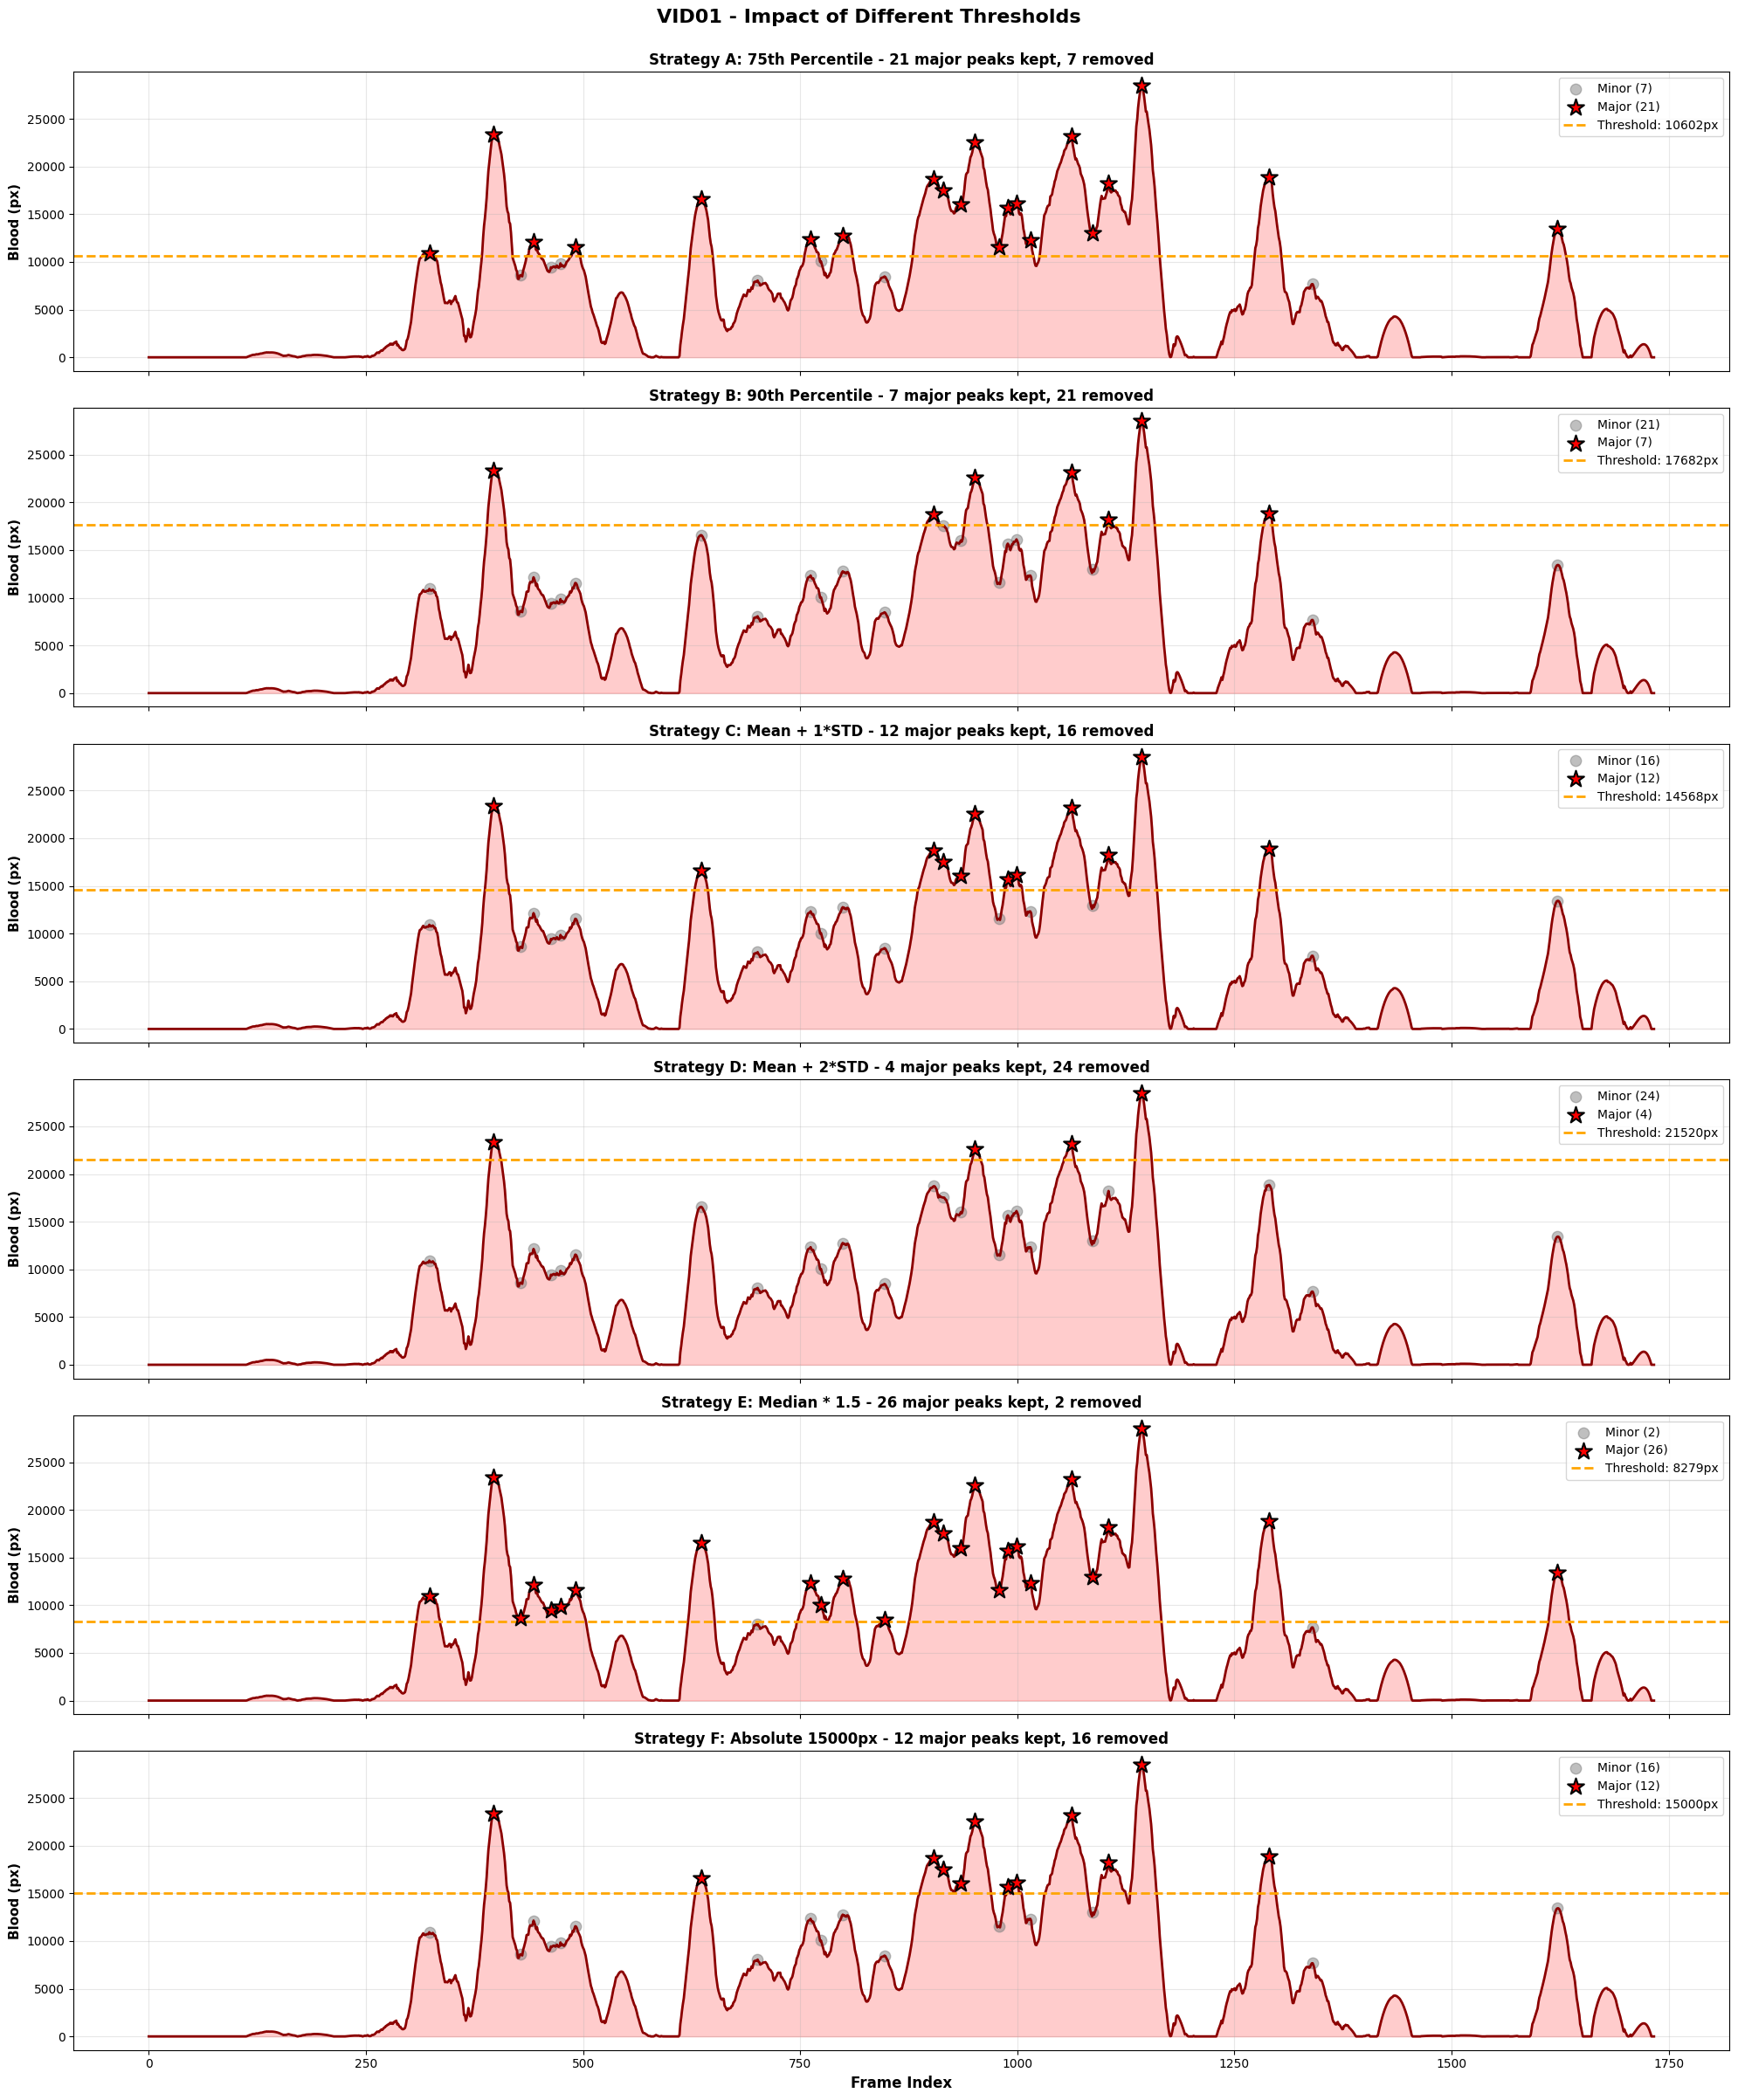

✅ Threshold comparison saved


In [6]:
# Cell 6: Visualize Impact of Different Thresholds
print("\nVisualizing threshold impacts...\n")

# Pick a sample video to show
sample_video = list(all_data.keys())[0]
sample_data = all_data[sample_video]

fig, axes = plt.subplots(len(strategies), 1, figsize=(20, 4*len(strategies)), sharex=True)

frames = np.arange(len(sample_data['smoothed_blood_areas']))
blood = sample_data['smoothed_blood_areas']
all_peaks_sample = sample_data['peaks']

for idx, (name, threshold) in enumerate(strategies.items()):
    ax = axes[idx]
    
    # Plot blood area
    ax.plot(frames, blood, color='darkred', linewidth=2)
    ax.fill_between(frames, 0, blood, alpha=0.2, color='red')
    
    # Separate major vs minor peaks
    major_peaks = []
    minor_peaks = []
    
    for peak in all_peaks_sample:
        if blood[peak] >= threshold:
            major_peaks.append(peak)
        else:
            minor_peaks.append(peak)
    
    # Plot minor peaks (gray)
    if len(minor_peaks) > 0:
        ax.scatter(minor_peaks, blood[minor_peaks],
                  color='gray', s=80, marker='o', alpha=0.5,
                  label=f'Minor ({len(minor_peaks)})')
    
    # Plot major peaks (red stars)
    if len(major_peaks) > 0:
        ax.scatter(major_peaks, blood[major_peaks],
                  color='red', s=200, marker='*', zorder=5,
                  edgecolors='black', linewidths=1.5,
                  label=f'Major ({len(major_peaks)})')
    
    # Threshold line
    ax.axhline(threshold, color='orange', linestyle='--', linewidth=2,
              label=f'Threshold: {threshold:.0f}px')
    
    ax.set_ylabel('Blood (px)', fontsize=11, fontweight='bold')
    ax.set_title(f'{name} - {len(major_peaks)} major peaks kept, {len(minor_peaks)} removed',
                fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Frame Index', fontsize=12, fontweight='bold')
plt.suptitle(f'{sample_video.upper()} - Impact of Different Thresholds',
            fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()
plt.savefig('threshold_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Threshold comparison saved")

In [7]:
# Cell 7: Recommendation & Selection
print("\n" + "=" * 80)
print("RECOMMENDED THRESHOLD")
print("=" * 80)
print()

# My recommendation: 75th percentile
RECOMMENDED_THRESHOLD = np.percentile(all_peak_heights, 75)
RECOMMENDED_STRATEGY = "75th Percentile"

print(f"🎯 RECOMMENDED: {RECOMMENDED_STRATEGY}")
print(f"   Threshold: {RECOMMENDED_THRESHOLD:.1f} pixels")
print()
print(f"Why this choice?")
print(f"  ✅ Data-driven (not arbitrary)")
print(f"  ✅ Keeps top 25% most severe bleeding events")
print(f"  ✅ Removes 75% of minor peaks (reduces false alarms)")
print(f"  ✅ Clinically relevant (focuses on major bleeding)")
print(f"  ✅ Still enough data for training (~{int(len(all_peak_heights) * 0.25)} peaks)")
print()

# Calculate impact
peaks_kept = np.sum(all_peak_heights >= RECOMMENDED_THRESHOLD)
peaks_removed = len(all_peak_heights) - peaks_kept

print(f"Impact on dataset:")
print(f"  Original peaks: {len(all_peak_heights)}")
print(f"  Major peaks (kept): {peaks_kept} ({100*peaks_kept/len(all_peak_heights):.1f}%)")
print(f"  Minor peaks (removed): {peaks_removed} ({100*peaks_removed/len(all_peak_heights):.1f}%)")
print()

# Estimate new class distribution
positive_frames_original = len(all_peak_heights) * 5  # Each peak labels 5 frames
positive_frames_new = peaks_kept * 5

total_frames = sum([d['num_frames'] for d in all_data.values()])
original_pct = 100 * positive_frames_original / total_frames
new_pct = 100 * positive_frames_new / total_frames

print(f"Estimated class distribution:")
print(f"  Original positive samples: ~{original_pct:.1f}%")
print(f"  New positive samples: ~{new_pct:.1f}%")
print(f"  Result: More focused on critical events!")

# Save threshold
threshold_info = {
    'strategy': RECOMMENDED_STRATEGY,
    'threshold': float(RECOMMENDED_THRESHOLD),
    'total_peaks': len(all_peak_heights),
    'peaks_kept': int(peaks_kept),
    'peaks_removed': int(peaks_removed),
    'pct_kept': float(100*peaks_kept/len(all_peak_heights)),
}

import json
with open('major_bleeding_threshold.json', 'w') as f:
    json.dump(threshold_info, f, indent=2)

print(f"\n✅ Threshold saved to: major_bleeding_threshold.json")


RECOMMENDED THRESHOLD

🎯 RECOMMENDED: 75th Percentile
   Threshold: 10602.4 pixels

Why this choice?
  ✅ Data-driven (not arbitrary)
  ✅ Keeps top 25% most severe bleeding events
  ✅ Removes 75% of minor peaks (reduces false alarms)
  ✅ Clinically relevant (focuses on major bleeding)
  ✅ Still enough data for training (~306 peaks)

Impact on dataset:
  Original peaks: 1226
  Major peaks (kept): 307 (25.0%)
  Minor peaks (removed): 919 (75.0%)

Estimated class distribution:
  Original positive samples: ~6.8%
  New positive samples: ~1.7%
  Result: More focused on critical events!

✅ Threshold saved to: major_bleeding_threshold.json



Showing before/after examples for 3 videos...



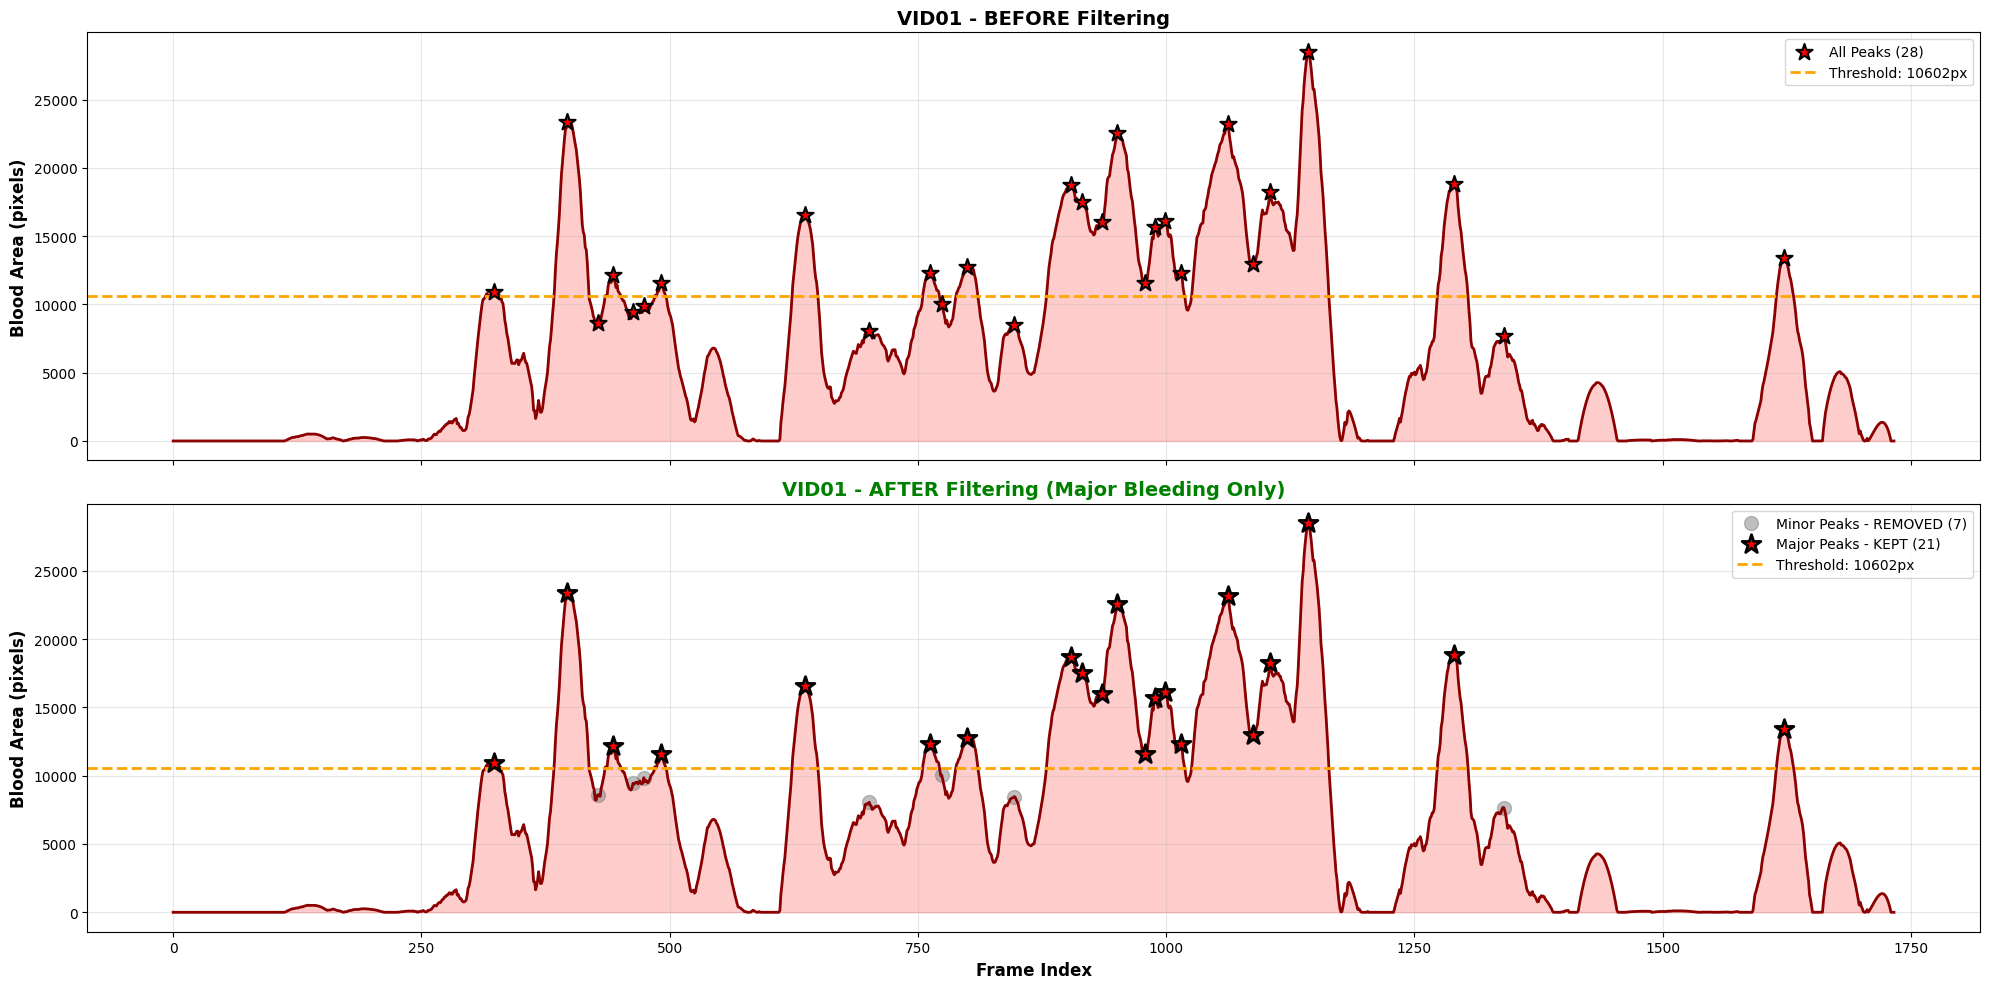

✅ VID01: 28 → 21 peaks (7 removed)


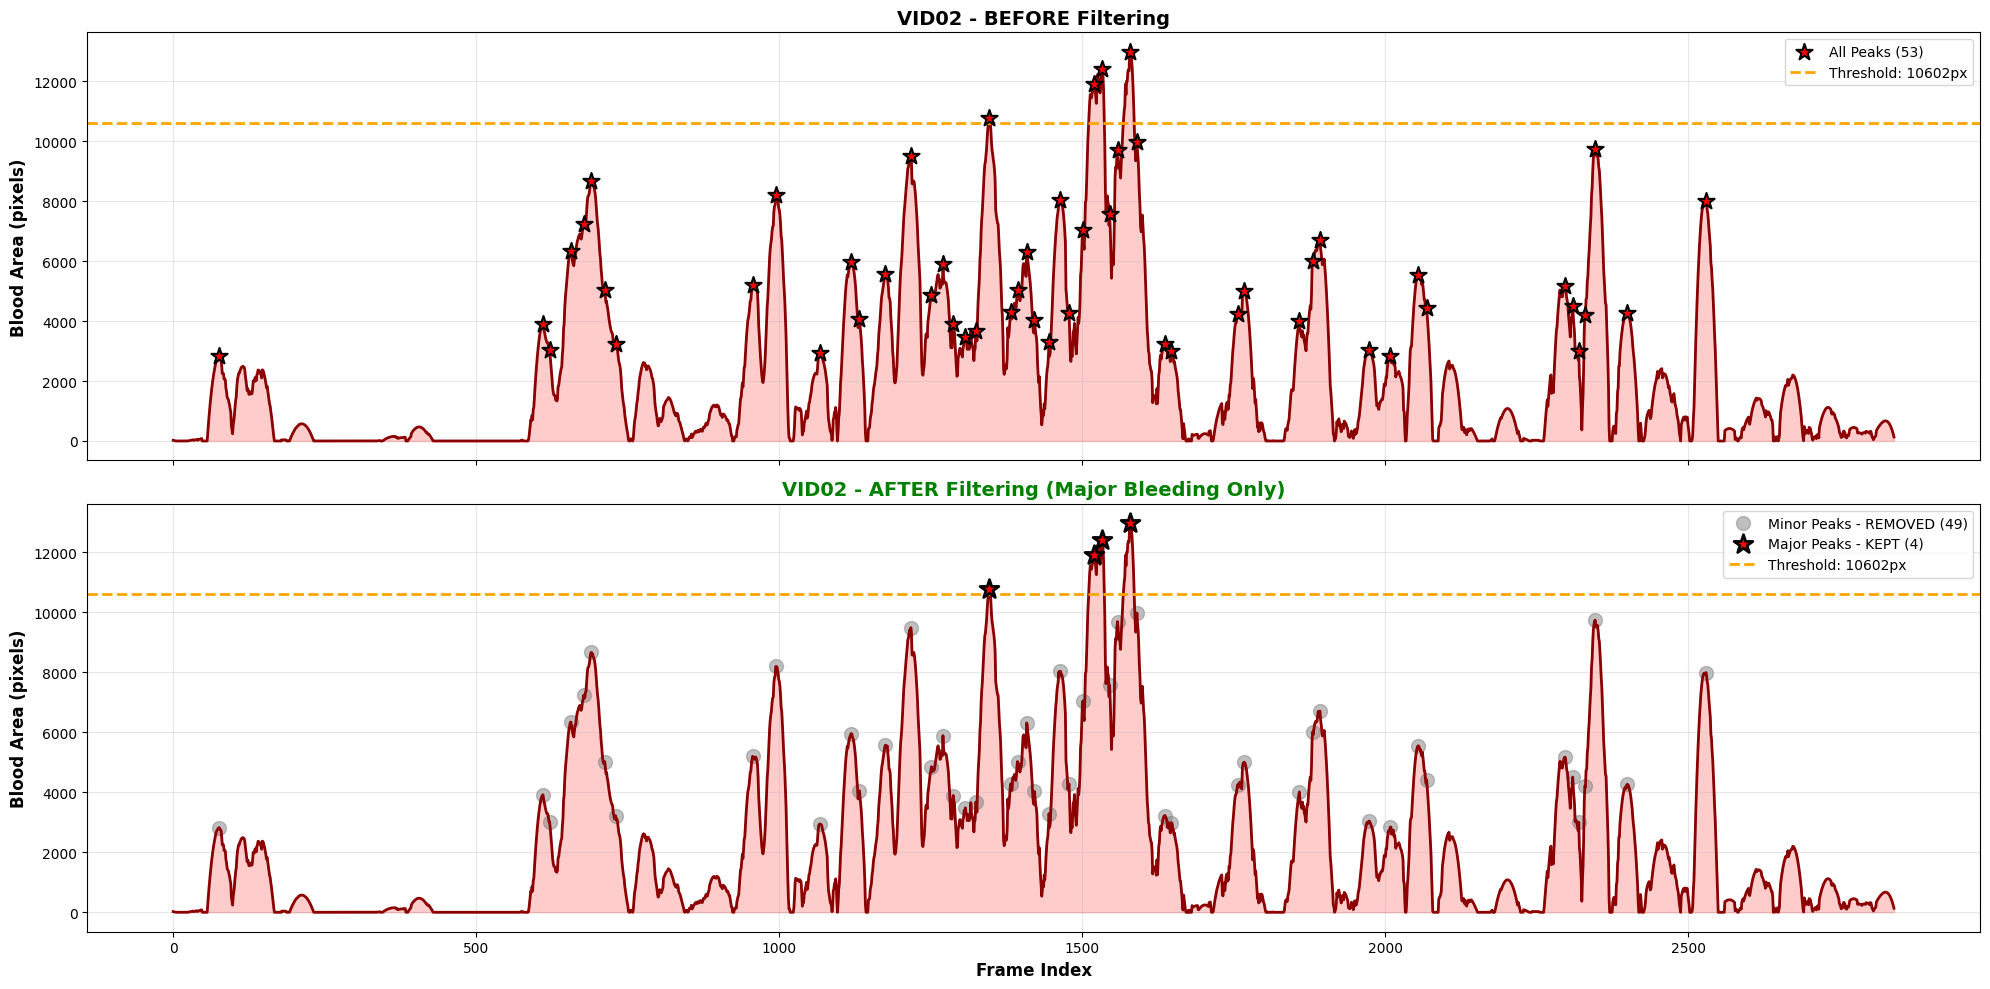

✅ VID02: 53 → 4 peaks (49 removed)


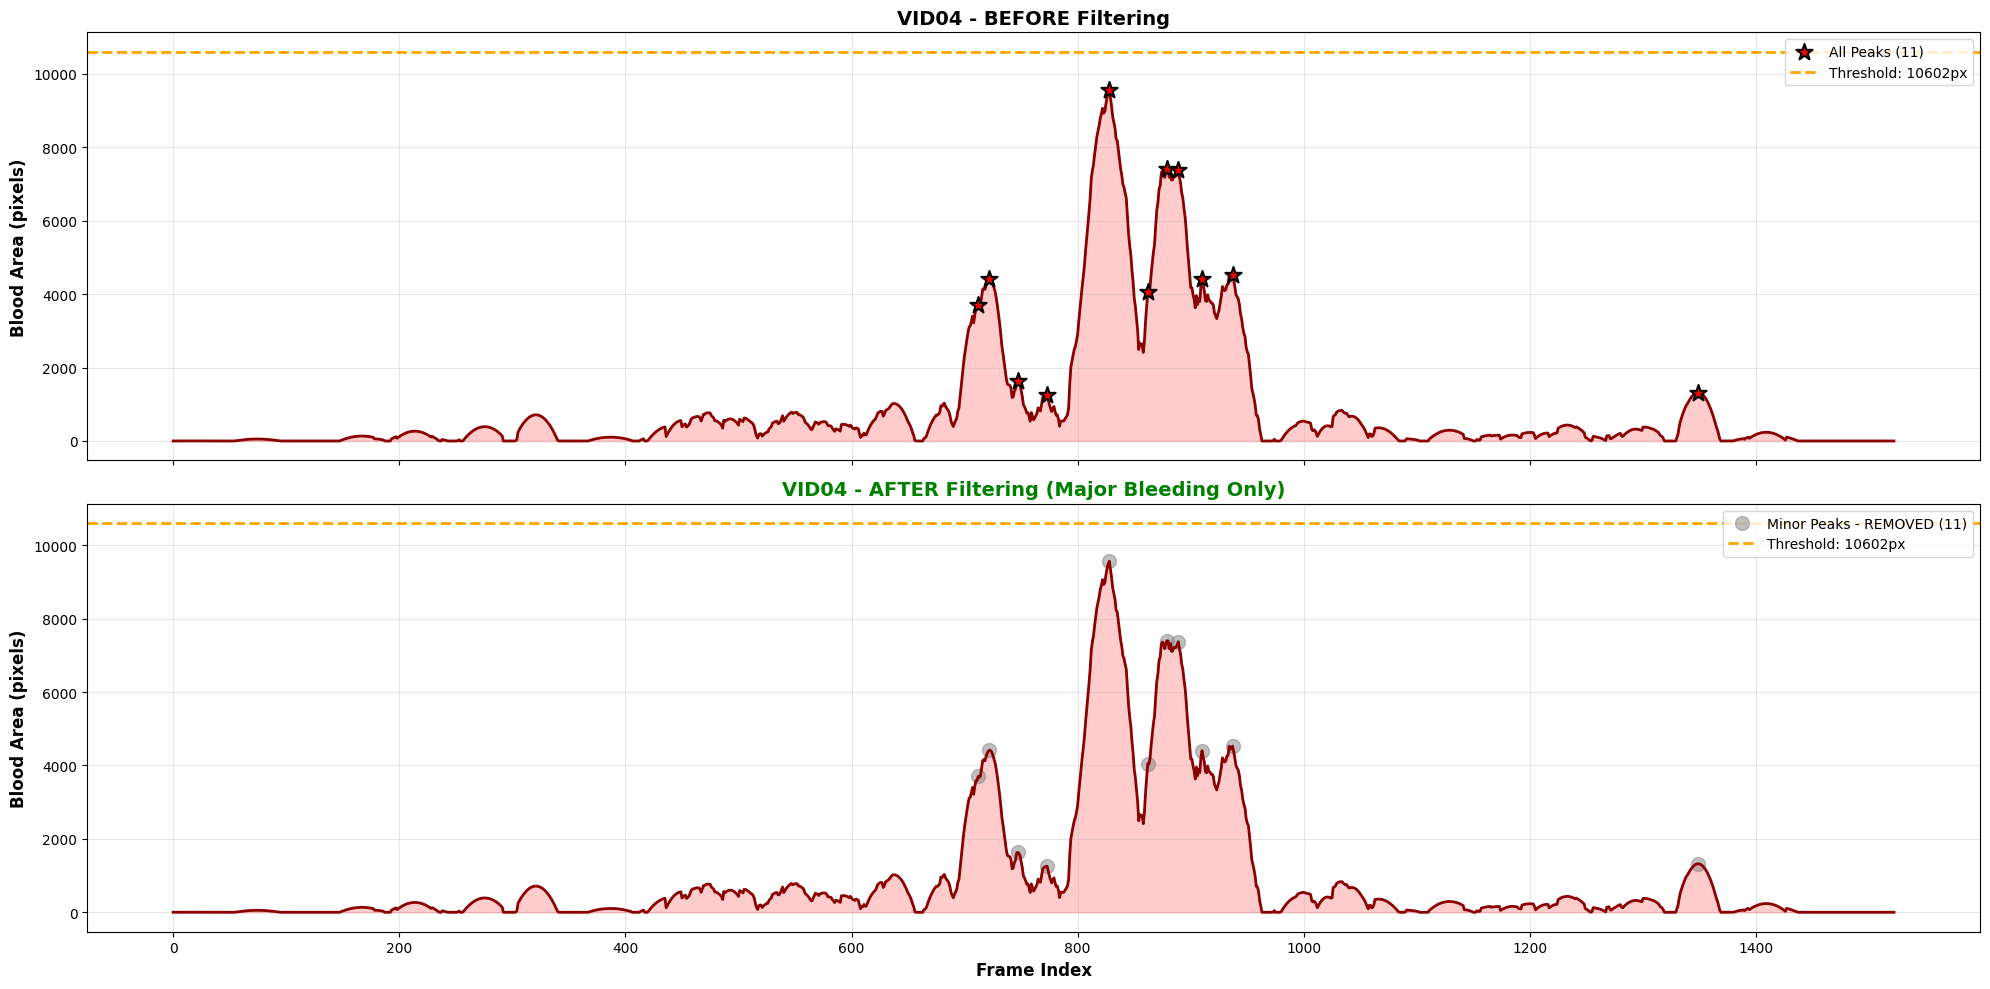

✅ VID04: 11 → 0 peaks (11 removed)

✅ Before/after examples saved


In [8]:
# Cell 8: Show Examples of Filtered Peaks
print("\nShowing before/after examples for 3 videos...\n")

for i in range(min(3, len(all_data))):
    video_id = list(all_data.keys())[i]
    data = all_data[video_id]
    
    frames = np.arange(len(data['smoothed_blood_areas']))
    blood = data['smoothed_blood_areas']
    all_peaks = data['peaks']
    
    # Separate peaks
    major_peaks = [p for p in all_peaks if blood[p] >= RECOMMENDED_THRESHOLD]
    minor_peaks = [p for p in all_peaks if blood[p] < RECOMMENDED_THRESHOLD]
    
    fig, axes = plt.subplots(2, 1, figsize=(20, 10), sharex=True)
    
    # BEFORE
    axes[0].plot(frames, blood, color='darkred', linewidth=2)
    axes[0].fill_between(frames, 0, blood, alpha=0.2, color='red')
    if len(all_peaks) > 0:
        axes[0].scatter(all_peaks, blood[all_peaks],
                       color='red', s=150, marker='*', zorder=5,
                       edgecolors='black', linewidths=1.5,
                       label=f'All Peaks ({len(all_peaks)})')
    axes[0].axhline(RECOMMENDED_THRESHOLD, color='orange', linestyle='--', linewidth=2,
                   label=f'Threshold: {RECOMMENDED_THRESHOLD:.0f}px')
    axes[0].set_ylabel('Blood Area (pixels)', fontsize=12, fontweight='bold')
    axes[0].set_title(f'{video_id.upper()} - BEFORE Filtering',
                     fontsize=14, fontweight='bold')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)
    
    # AFTER
    axes[1].plot(frames, blood, color='darkred', linewidth=2)
    axes[1].fill_between(frames, 0, blood, alpha=0.2, color='red')
    
    if len(minor_peaks) > 0:
        axes[1].scatter(minor_peaks, blood[minor_peaks],
                       color='gray', s=100, marker='o', alpha=0.5,
                       label=f'Minor Peaks - REMOVED ({len(minor_peaks)})')
    
    if len(major_peaks) > 0:
        axes[1].scatter(major_peaks, blood[major_peaks],
                       color='red', s=200, marker='*', zorder=5,
                       edgecolors='black', linewidths=2,
                       label=f'Major Peaks - KEPT ({len(major_peaks)})')
    
    axes[1].axhline(RECOMMENDED_THRESHOLD, color='orange', linestyle='--', linewidth=2,
                   label=f'Threshold: {RECOMMENDED_THRESHOLD:.0f}px')
    axes[1].set_xlabel('Frame Index', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Blood Area (pixels)', fontsize=12, fontweight='bold')
    axes[1].set_title(f'{video_id.upper()} - AFTER Filtering (Major Bleeding Only)',
                     fontsize=14, fontweight='bold', color='green')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'before_after_{video_id}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✅ {video_id}: {len(all_peaks)} → {len(major_peaks)} peaks ({len(minor_peaks)} removed)")

print("\n✅ Before/after examples saved")

In [9]:
# Cell 9: Final Summary
print("\n" + "=" * 80)
print("PEAK ANALYSIS COMPLETE - SUMMARY")
print("=" * 80)
print()
print(f"✅ Analyzed {len(all_data)} videos")
print(f"✅ Examined {len(all_peak_heights)} total peaks")
print(f"✅ Selected threshold: {RECOMMENDED_THRESHOLD:.1f} pixels ({RECOMMENDED_STRATEGY})")
print(f"✅ This will keep {peaks_kept} major bleeding events ({100*peaks_kept/len(all_peak_heights):.1f}%)")
print()
print(f"📁 Generated files:")
print(f"  - peak_distribution_analysis.png")
print(f"  - threshold_comparison.png")
print(f"  - before_after_*.png (example videos)")
print(f"  - major_bleeding_threshold.json (threshold config)")
print()
print(f"🎯 Next steps:")
print(f"  1. Review the visualizations")
print(f"  2. Confirm the threshold looks good")
print(f"  3. Run the updated training notebooks with filtered peaks")
print(f"  4. Train model on major bleeding events only!")
print()
print("=" * 80)


PEAK ANALYSIS COMPLETE - SUMMARY

✅ Analyzed 45 videos
✅ Examined 1226 total peaks
✅ Selected threshold: 10602.4 pixels (75th Percentile)
✅ This will keep 307 major bleeding events (25.0%)

📁 Generated files:
  - peak_distribution_analysis.png
  - threshold_comparison.png
  - before_after_*.png (example videos)
  - major_bleeding_threshold.json (threshold config)

🎯 Next steps:
  1. Review the visualizations
  2. Confirm the threshold looks good
  3. Run the updated training notebooks with filtered peaks
  4. Train model on major bleeding events only!

